In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.widgets as mwidgets
import matplotlib.path as mpath
import numpy as np
import matplotlib.path as mpath

In [2]:
%matplotlib widget

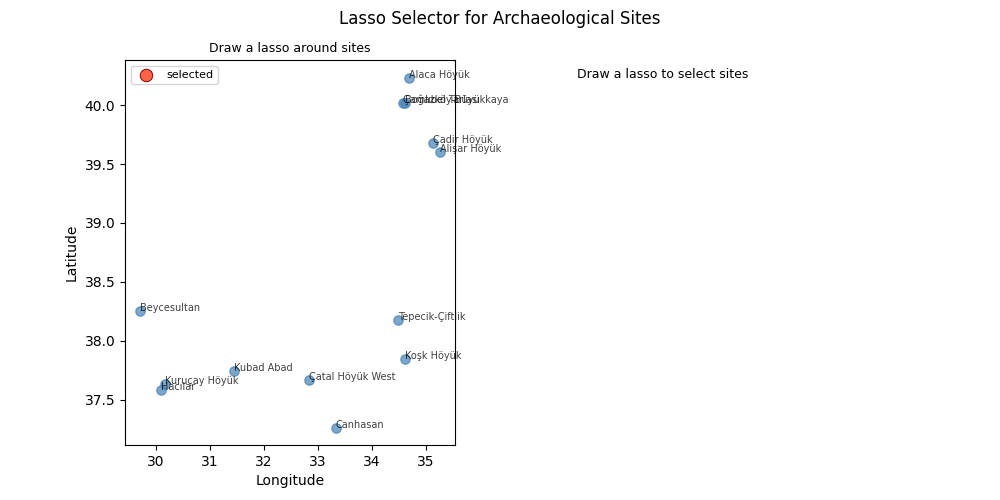

In [3]:
# Load data
file_path = "/Users/evijonas/python/archyviz/archyviz-site-geocoords.xlsx"
df = pd.read_excel(file_path)

# Keep only rows with coordinates
df = df.dropna(subset=["Latitude", "Longitude"]).copy()

# Coordinates
x = df["Longitude"].to_numpy()
y = df["Latitude"].to_numpy()
sites = df["Site"].to_numpy()
xy = np.c_[x, y]

# Plot layout
fig, (ax_map, ax_list) = plt.subplots(1, 2, figsize=(10, 5))
fig.subplots_adjust(wspace=0.35)
fig.suptitle("Lasso Selector for Archaeological Sites", fontsize=12)

# Site scatterplot
ax_map.scatter(x, y, c="steelblue", s=45, alpha=0.7, zorder=2)

selected_sc = ax_map.scatter(
    [], [], c="tomato", s=80, zorder=5,
    edgecolors="darkred", linewidths=0.7,
    label="selected"
)

for site, lon, lat in zip(sites, x, y):
    ax_map.text(lon, lat, site, fontsize=7, alpha=0.75)

ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")
ax_map.set_title("Draw a lasso around sites", fontsize=9)
ax_map.legend(fontsize=8)

# Text panel for selected sites
ax_list.axis("off")
selected_text = ax_list.text(
    0.02, 0.98,
    "Draw a lasso to select sites",
    transform=ax_list.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

def on_lasso(verts):
    path = mpath.Path(verts)
    mask = path.contains_points(xy)
    indices = np.where(mask)[0]

    if len(indices) > 0:
        selected_sc.set_offsets(xy[indices])

        selected_sites = sites[indices]
        site_list = "\n".join(f"- {s}" for s in selected_sites)

        selected_text.set_text(
            f"{len(indices)} sites selected:\n\n{site_list}"
        )
    else:
        selected_sc.set_offsets(np.empty((0, 2)))
        selected_text.set_text("No sites selected")

    fig.canvas.draw_idle()

lasso = mwidgets.LassoSelector(ax_map, on_lasso, useblit=False)

plt.show()

SECOND TRY

filepath

In [4]:
file_path = "/Users/evijonas/python/archyviz/archy494data_burialcoords.xlsx"

Re-Creating the 'totals' data frame from the heatmaps notebook

In [5]:
#create 'burial_tables' df
burial_tables = pd.read_excel(
    file_path,
    sheet_name="burialtables",
    skiprows=2
)

burial_tables.columns = (
    burial_tables.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

#clean & pivot wide
df = burial_tables.copy()
s = df["site"].astype(str)

is_subadult_marker = s.str.contains("Subadult", case=False, na=False)
df["age_group"] = np.where(is_subadult_marker.cumsum() > 0, "Subadult", "Adult")

bad_sites = {
    "Site",
    "Adults",
    "Subadults",
    "Table 1: Adult Burials",
    "Table 2: Subadult Burials"
}

df = df[~df["site"].isin(bad_sites)].copy()
df = df.dropna(subset=["site", "sub_region"])

df["total"] = pd.to_numeric(
    df["adult_burials"].replace({"-": 0}),
    errors="coerce"
)

df = df.dropna(subset=["total"])

wide = df.pivot_table(
    index=["site", "sub_region"],
    columns="age_group",
    values="total",
    aggfunc="sum"
)

wide = wide.reindex(columns=["Adult", "Subadult"])

#create 'totals' df
totals = (
    wide
    .rename(columns={"Adult": "adult_total", "Subadult": "subadult_total"})
    .reset_index()
)

totals[["adult_total", "subadult_total"]] = (
    totals[["adult_total", "subadult_total"]]
    .fillna(0)
    .astype(int)
)

totals.head()

#create 'analysis' df
burial_cols = [
    "intramural",
    "extramural",
    "pithos_burials",
    "simple_internment",
    "refuse_pit",
    "other",
]

burial_counts = burial_tables.copy()

bad_sites = {
    "Site",
    "Adults",
    "Subadults",
    "Table 1: Adult Burials",
    "Table 2: Subadult Burials"
}

burial_counts = burial_counts[~burial_counts["site"].isin(bad_sites)].copy()
burial_counts = burial_counts.dropna(subset=["site", "sub_region"])

burial_counts[burial_cols] = (
    burial_counts[burial_cols]
    .replace("-", 0)
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)

burial_counts_by_site = (
    burial_counts
    .groupby("site", as_index=False)[burial_cols]
    .sum()
)

analysis_df = totals.merge(
    burial_counts_by_site,
    on="site",
    how="left"
)

analysis_df[burial_cols] = analysis_df[burial_cols].fillna(0)

/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_82475/3730494993.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["adult_burials"].replace({"-": 0}),
/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_82475/3730494993.py:90: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("-", 0)


Merging tranformed dataframes (coordinates + totals)

In [6]:
file_path = "/Users/evijonas/python/archyviz/archy494data_burialcoords.xlsx"

geo_df = pd.read_excel(file_path, sheet_name=4)

geo_df.columns = (
    geo_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

#creating a merged dataframe (map coords and burial totals)
map_df = geo_df.merge(
    analysis_df[
        [
            "site",
            "adult_total",
            "subadult_total",
            "intramural",
            "extramural",
            "pithos_burials",
            "simple_internment",
            "refuse_pit",
            "other",
        ]
    ],
    on="site",
    how="left"
)

#finishing? the map_df
needed_cols = [
    "adult_total",
    "subadult_total",
    "intramural",
    "extramural",
    "pithos_burials",
    "simple_internment",
    "refuse_pit",
    "other"
]

map_df[needed_cols] = (
    map_df[needed_cols]
        .replace("-", 0)
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
)

#cleaning coords
map_df = map_df.dropna(subset=["latitude", "longitude"]).copy()

map_df[["adult_total", "subadult_total"]] = (
    map_df[["adult_total", "subadult_total"]]
    .fillna(0)
    .astype(int)
)

x = map_df["longitude"].to_numpy()
y = map_df["latitude"].to_numpy()
sites = map_df["site"].to_numpy()
adult_totals = map_df["adult_total"].to_numpy()
subadult_totals = map_df["subadult_total"].to_numpy()
xy = np.c_[x, y]

now render results
make interaction happen

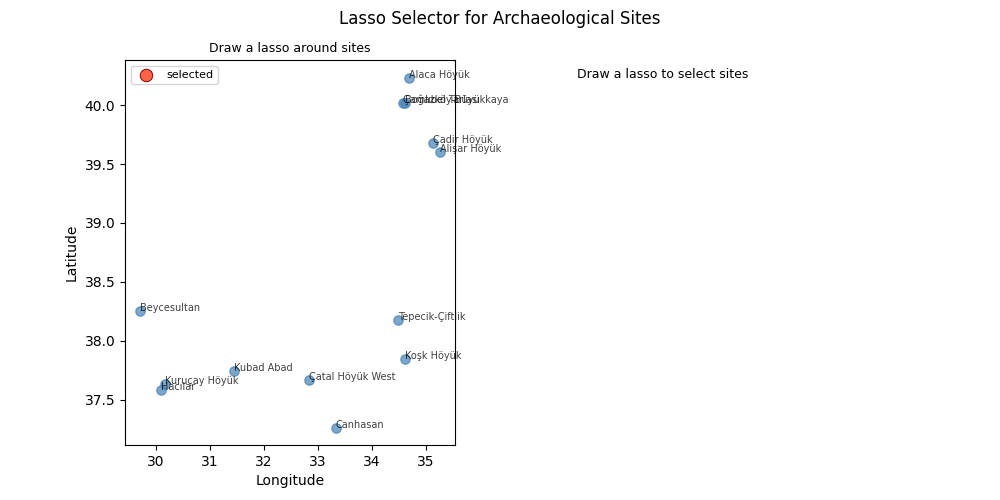

In [7]:
# Load data
#file_path = "/Users/evijonas/python/archyviz/archyviz-site-geocoords.xlsx"
#df = pd.read_excel(file_path)

# Keep only rows with coordinates
df = map_df
#df.dropna(subset=["Latitude", "Longitude"]).copy()

# Coordinates
x = map_df["longitude"].to_numpy()
y = map_df["latitude"].to_numpy()
sites = map_df["site"].to_numpy()
adult_totals = map_df["adult_total"].to_numpy()
subadult_totals = map_df["subadult_total"].to_numpy()

xy = np.c_[x, y]

# Plot layout
fig, (ax_map, ax_list) = plt.subplots(1, 2, figsize=(10, 5))
fig.subplots_adjust(wspace=0.35)
fig.suptitle("Lasso Selector for Archaeological Sites", fontsize=12)

# Site scatterplot
ax_map.scatter(x, y, c="steelblue", s=45, alpha=0.7, zorder=2)

selected_sc = ax_map.scatter(
    [], [], c="tomato", s=80, zorder=5,
    edgecolors="darkred", linewidths=0.7,
    label="selected"
)

for site, lon, lat in zip(sites, x, y):
    ax_map.text(lon, lat, site, fontsize=7, alpha=0.75)

ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")
ax_map.set_title("Draw a lasso around sites", fontsize=9)
ax_map.legend(fontsize=8)

# Text panel for selected sites
ax_list.axis("off")
selected_text = ax_list.text(
    0.02, 0.98,
    "Draw a lasso to select sites",
    transform=ax_list.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

def on_lasso(verts):
    path = mpath.Path(verts)
    mask = path.contains_points(xy)
    indices = np.where(mask)[0]

    if len(indices) > 0:
        selected_sc.set_offsets(xy[indices])

        selected_sites = sites[indices]
        site_list = "\n".join(f"- {s}" for s in selected_sites)

        adult_sum = np.nansum(adult_totals[indices])
        subadult_sum = np.nansum(subadult_totals[indices])

        if subadult_sum > 0:
            ratio = (adult_sum / subadult_sum) * 100
            ratio_text = (
                f"\n\nAggregate adult/subadult ratio:\n"
                f"{ratio:.1f}%\n"
                f"({adult_sum:.0f} adult / {subadult_sum:.0f} subadult)"
            )
        else:
            ratio_text = (
                f"\n\nAggregate adult/subadult ratio:\n"
                f"undefined — no subadult burials selected\n"
                f"({adult_sum:.0f} adult / {subadult_sum:.0f} subadult)"
            )

        selected_text.set_text(
            f"{len(indices)} sites selected:\n\n{site_list}{ratio_text}"
        )

    else:
        selected_sc.set_offsets(np.empty((0, 2)))
        selected_text.set_text("No sites selected")

    fig.canvas.draw_idle()

lasso = mwidgets.LassoSelector(ax_map, on_lasso, useblit=False)

plt.show()

sick, that worked

now lets add graphics on the left

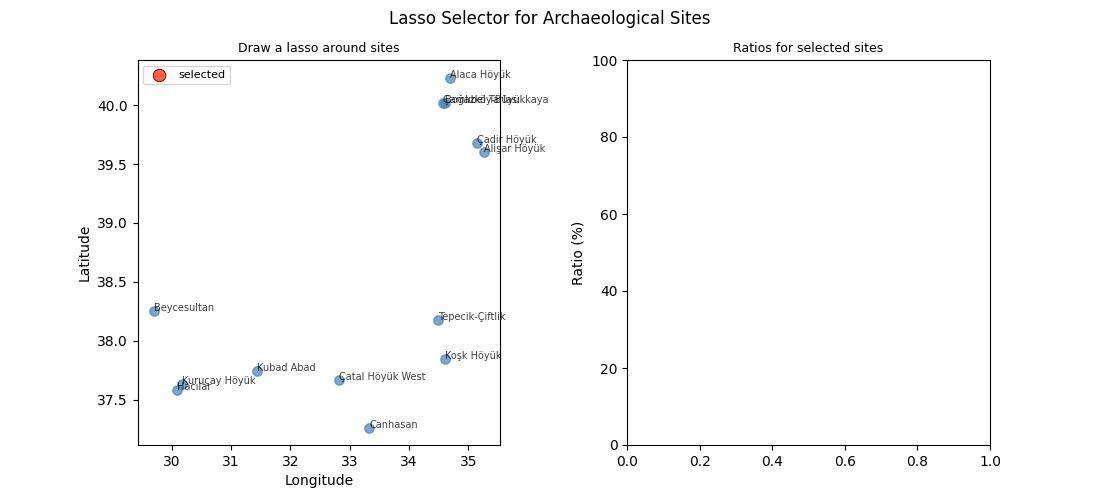

In [8]:
# Keep only rows with coordinates
df = map_df

# Coordinates
x = map_df["longitude"].to_numpy()
y = map_df["latitude"].to_numpy()
sites = map_df["site"].to_numpy()
xy = np.c_[x, y]

# Plot layout
fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(11, 5))
fig.subplots_adjust(wspace=0.35)
fig.suptitle("Lasso Selector for Archaeological Sites", fontsize=12)

# Site scatterplot
ax_map.scatter(x, y, c="steelblue", s=45, alpha=0.7, zorder=2)

selected_sc = ax_map.scatter(
    [], [], c="tomato", s=80, zorder=5,
    edgecolors="darkred", linewidths=0.7,
    label="selected"
)

for site, lon, lat in zip(sites, x, y):
    ax_map.text(lon, lat, site, fontsize=7, alpha=0.75)

ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")
ax_map.set_title("Draw a lasso around sites", fontsize=9)
ax_map.legend(fontsize=8)

# Bar chart panel
ax_bar.set_title("Ratios for selected sites", fontsize=9)
ax_bar.set_ylabel("Ratio (%)")
ax_bar.set_ylim(0, 100)

def safe_ratio(numerator, denominator):
    if denominator == 0:
        return np.nan
    return (numerator / denominator) * 100

def on_lasso(verts):
    path = mpath.Path(verts)
    mask = path.contains_points(xy)
    indices = np.where(mask)[0]

    ax_bar.clear()
    ax_bar.set_title("Ratios for selected sites", fontsize=9)
    ax_bar.set_ylabel("Ratio (%)")

    if len(indices) > 0:
        selected_sc.set_offsets(xy[indices])
        selected = map_df.iloc[indices]

        ratio_labels = [
            "Adult/\nSubadult",
            "Intramural/\nExtramural",
            "Pithos/\nOther",
            "Simple/\nOther",
            "Refuse pit/\nOther"
        ]

        ratio_values = [
            safe_ratio(selected["adult_total"].sum(), selected["subadult_total"].sum()),
            safe_ratio(selected["intramural"].sum(), selected["extramural"].sum()),
            safe_ratio(selected["pithos_burials"].sum(), selected["other"].sum()),
            safe_ratio(selected["simple_internment"].sum(), selected["other"].sum()),
            safe_ratio(selected["refuse_pit"].sum(), selected["other"].sum()),
        ]

        ax_bar.bar(ratio_labels, ratio_values)
        ax_bar.set_ylim(0, max(100, np.nanmax(ratio_values) * 1.15))
        ax_bar.tick_params(axis="x", rotation=35)

        for i, value in enumerate(ratio_values):
            if np.isnan(value):
                ax_bar.text(i, 2, "N/A", ha="center", va="bottom", fontsize=8)
            else:
                ax_bar.text(i, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=8)

    else:
        selected_sc.set_offsets(np.empty((0, 2)))
        ax_bar.text(0.5, 0.5, "No sites selected", transform=ax_bar.transAxes,
                    ha="center", va="center")

    fig.canvas.draw_idle()

lasso = mwidgets.LassoSelector(ax_map, on_lasso, useblit=False)

plt.show()